In [1]:
import pixeltable as pxt
import os

In [2]:
!pip install torchvision

### User-defined functions

In [3]:
pxt.drop_table("test.table", if_not_exists="ignore")
pxt.drop_table("video_table", force=True)

Connected to Pixeltable database at: postgresql+psycopg://postgres:@/pixeltable?host=/Users/antonmasiukevich/.pixeltable/pgdata


In [4]:
my_table = pxt.create_table(
    "test.table",
    schema={
        "raw_text": pxt.String,
    },
    if_exists="replace_force"
)

my_table.insert([
    {'raw_text': 'My name is Anton.'},
    {"raw_text": "My name is Jan."}
])

Created table 'table'.
Inserting rows into `table`: 2 rows [00:00, 169.89 rows/s]
Inserted 2 rows with 0 errors.


2 rows inserted, 2 values computed.

Two user-defined functions. One is extracting the name and the other is saying hello.

In [5]:
import re


@pxt.udf
def say_hello(name: pxt.type_system.String) -> pxt.type_system.String:
    return f"Hello, {name}!"


@pxt.udf
def extract_name(text: pxt.type_system.String) -> pxt.type_system.String:
    match = re.search(r"My name is (\w+)", text)
    if match:
        return match.group(1)
    return "Unknown"

In [6]:
### Adding columns
my_table.add_computed_column(
    cleaned_text=extract_name(my_table.raw_text)
)
my_table.add_computed_column(
    last_text=say_hello(my_table.cleaned_text)   
)

Added 2 column values with 0 errors.
Added 2 column values with 0 errors.


2 rows updated, 4 values computed.

In [7]:
my_table.show()

raw_text,cleaned_text,last_text
My name is Anton.,Anton,"Hello, Anton!"
My name is Jan.,Jan,"Hello, Jan!"


In [8]:
my_table.insert([
    {'raw_text': 'My name is Alice.'},
    {"raw_text": "My name is Bob."}
])

Inserting rows into `table`: 2 rows [00:00, 967.66 rows/s]
Inserted 2 rows with 0 errors.


2 rows inserted, 10 values computed.

In [9]:
my_table.show()

raw_text,cleaned_text,last_text
My name is Anton.,Anton,"Hello, Anton!"
My name is Jan.,Jan,"Hello, Jan!"
My name is Alice.,Alice,"Hello, Alice!"
My name is Bob.,Bob,"Hello, Bob!"


### 2. Pixeltable queries

In [10]:
my_table.select(
    my_table.raw_text,
    my_table.cleaned_text,
    my_table.last_text
).where(my_table.last_text == "Hello, Anton!").show()

raw_text,cleaned_text,last_text
My name is Anton.,Anton,"Hello, Anton!"


## Multimodal pipeline

In [11]:
### Inserting the video
video_path = os.path.normpath(os.path.join(os.getcwd(), "../data/pass_the_butter_rick_and_morty.mp4"))

### 1/ Outlining the process

1. Create a new table
2. Audio pipeline
   <br>
   a. Audio Channel -> Split into Chunks -> Transcribe -> **Extract** -> Embed Transcriptions
3. Video Captions pipeline
   <br>
   a. Video Channel -> Split into Frames -> Resize -> Caption -> Embed Captions
4. Video Frames pipeline
   <br>
   a. Video Channel -> Sample Frames -> Resize -> Embed Frames

### 2/ Implementing and understanding the workflow

In [12]:
### Helpers

import pixeltable as pxt

from pixeltable.functions import openai
from pixeltable.functions.huggingface import clip
from pixeltable.functions.openai import embeddings, vision

from pixeltable.functions.video import extract_audio
from pixeltable.iterators.audio import AudioSplitter
from pixeltable.iterators.video import FrameIterator
from PIL import Image

@pxt.udf
def extract_text_from_chunk(transcript: pxt.type_system.Json) -> str:
    return f"{transcript['text']}"

@pxt.udf
def resize_image(image: pxt.type_system.Image, width: int, height: int) -> pxt.type_system.Image:
    if not isinstance(image, Image.Image):
        raise TypeError("Input must be a PIL Image")
    image.thumbnail((width, height))
    return image

In [13]:
video_table = pxt.create_table(
    "video_table",
    schema={"video": pxt.Video},
    if_exists="replace_force"
)

Created table 'video_table'.


In [14]:
video_table.insert([{'video': video_path}])

Inserting rows into `video_table`: 1 rows [00:00, 565.27 rows/s]
Inserted 1 row with 0 errors.


1 row inserted, 2 values computed.

### Audio pipeline

In [15]:
### Adding an audio extraction column

audio_view_name = "audio_chunks_view"

video_table.add_computed_column(
    audio_extract1=extract_audio(video_table.video, format="mp3"), if_exists="ignore"
)

audio_chunks = pxt.create_view(
    audio_view_name,
    video_table,
    iterator=AudioSplitter.create(
        audio=video_table.audio_extract1,
        chunk_duration_sec=10,
        overlap_sec=0,
        min_chunk_duration_sec=1
    ),
    if_exists="replace_force"
)

audio_chunks.add_computed_column(
    transcription=openai.transcriptions(
        audio=audio_chunks.audio_chunk,
        model="whisper-1",
    ),
    if_exists="ignore"
)

audio_chunks.add_computed_column(
    chunk_text=extract_text_from_chunk(audio_chunks.transcription),
    if_exists="ignore"
)

audio_chunks.add_embedding_index(
    column=audio_chunks.chunk_text,
    string_embed=embeddings.using(model="text-embedding-3-small"),
    if_exists="ignore",
    idx_name="chunks_index"
)

Added 1 column value with 0 errors.
Inserting rows into `audio_chunks_view`: 6 rows [00:00, 4548.31 rows/s]
Added 6 column values with 0 errors.
Added 6 column values with 0 errors.


### Image modality

In [16]:
import numpy as np

@pxt.udf
def clip_function(image: Image.Image) -> pxt.Array[(512,), pxt.Float]:
    import torch
    # return torch.tensor([1 for _ in range(1536)])
    return np.array([1 for _ in range(512)])

In [17]:
### Frame processing
frames_view_name = "video_frames_view"
frames_view = pxt.create_view(
    frames_view_name,
    video_table,
    iterator=FrameIterator.create(video=video_table.video, fps=0.5),
    if_exists="ignore"
)

frames_view.add_computed_column(
    resized_frame=resize_image(frames_view.frame, width=1280, height=720)
)

frames_view.add_embedding_index(
    column=frames_view.resized_frame,
    image_embed=clip_function,#clip.using(model_id="openai/clip-vit-base-patch32"),
    if_exists="replace_force",
)

frames_view.add_computed_column(
    im_caption=vision(
        prompt="Describe the image in a concise manner.",
        image=frames_view.resized_frame,
        model="gpt-4o-mini"
    )
)

frames_view.add_embedding_index(
    column=frames_view.im_caption,
    string_embed=embeddings.using(model="text-embedding-3-small"),
    if_exists="replace_force"
)

Inserting rows into `video_frames_view`: 31 rows [00:00, 16517.20 rows/s]
Added 31 column values with 0 errors.
Added 31 column values with 0 errors.


resized_frame
""
""
""

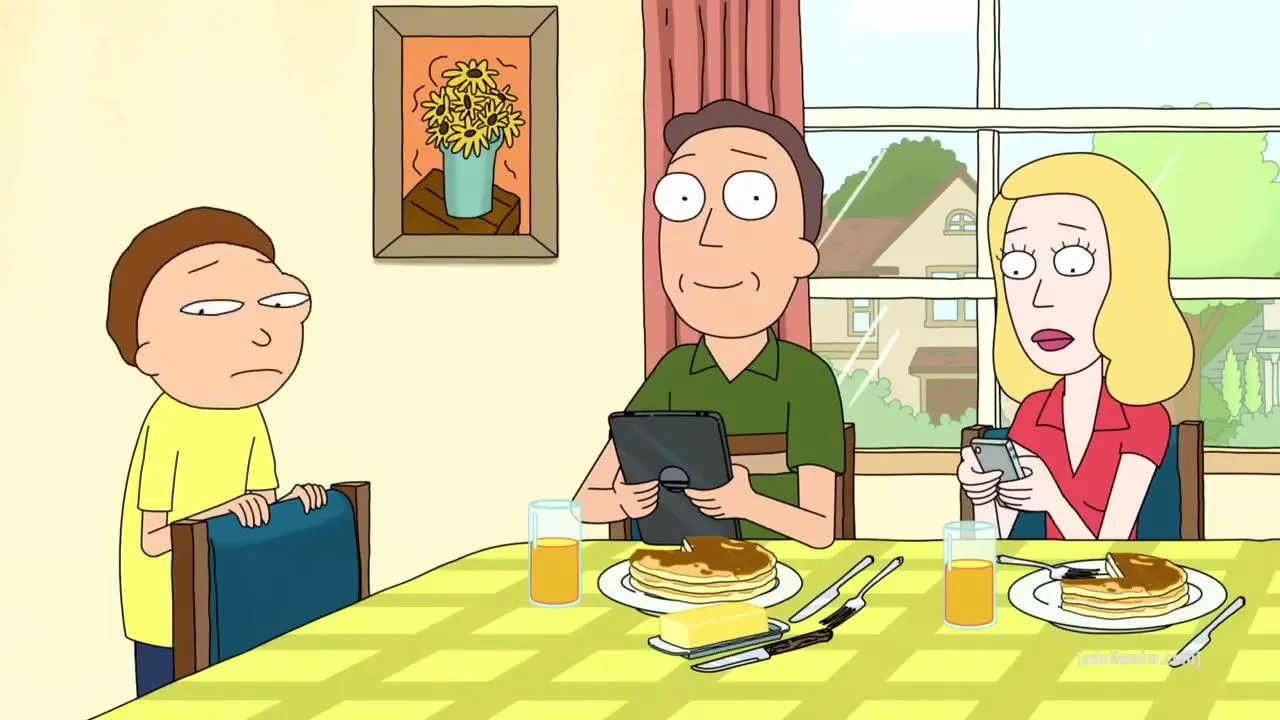
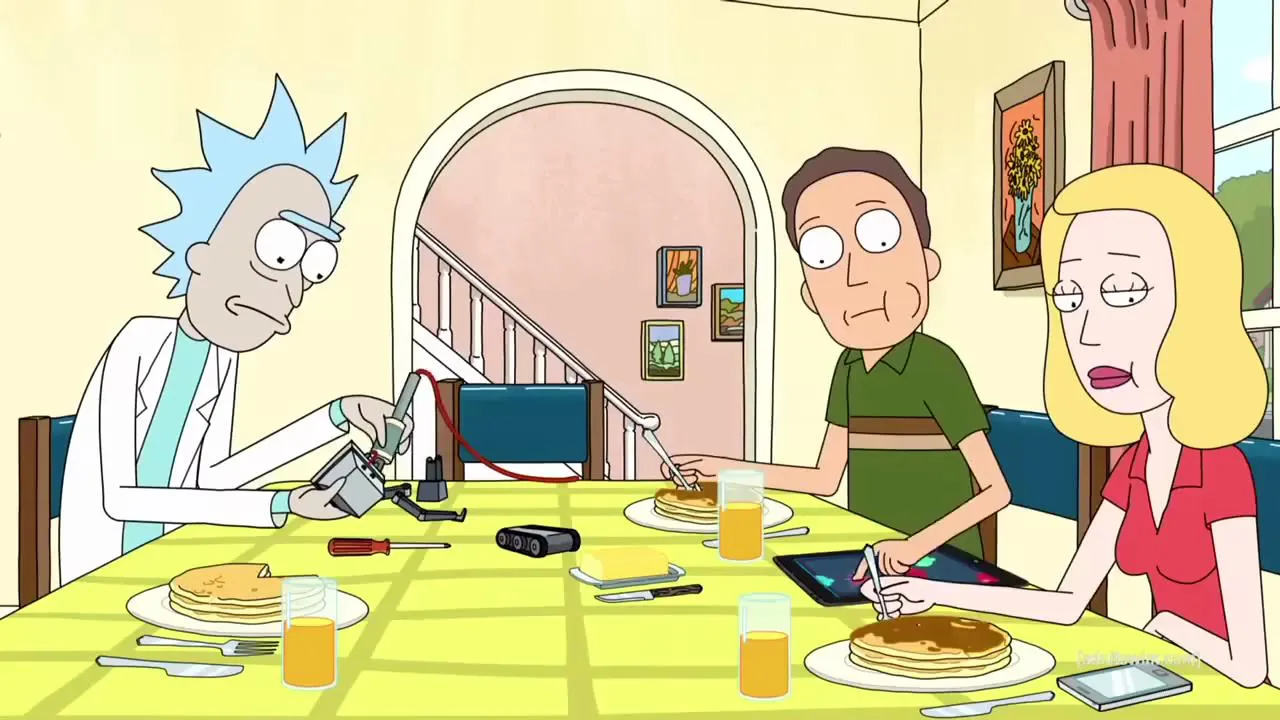
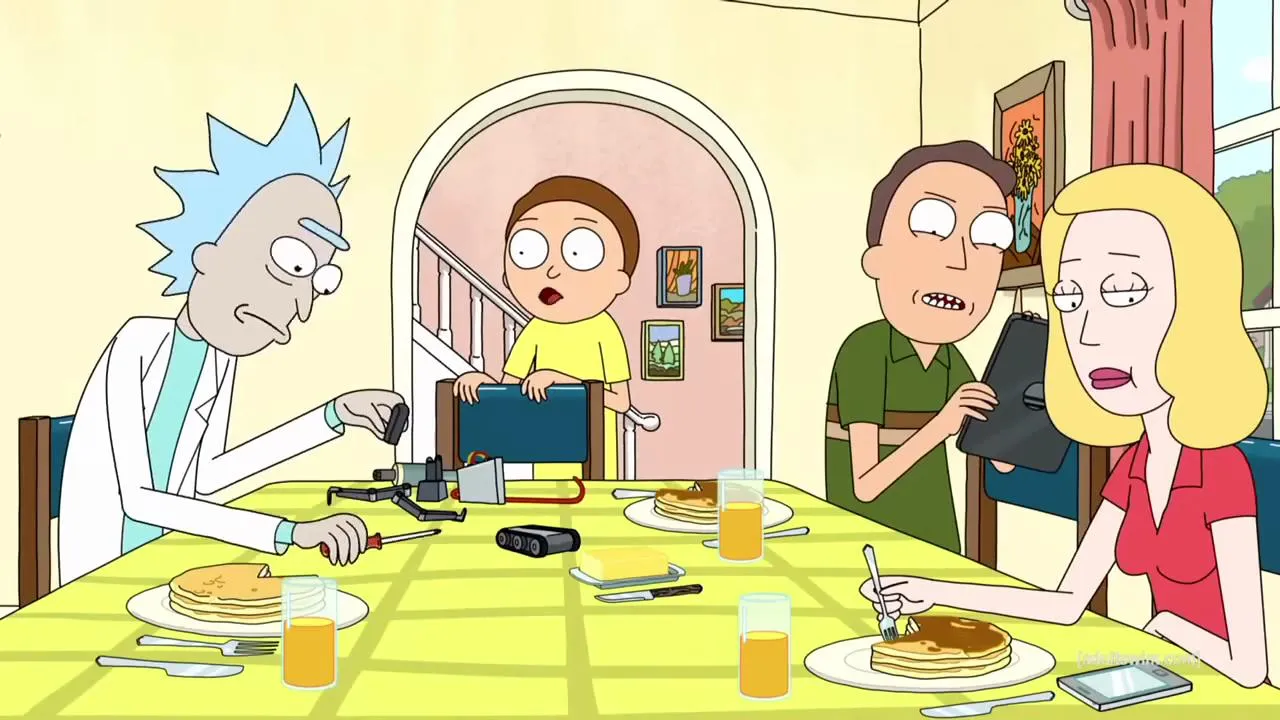

In [18]:
frames_view.select(
    frames_view.resized_frame
).show(3)